# Store Performance Segmentation

Physical stores only — StoreKey 0 (online) excluded throughout.

Source: stores_clean.parquet, sales_clean.parquet

### Imports

In [1]:
import pandas as pd
from src.analysis import store_perf as sp
from src.viz import base

### Load Data

In [2]:
stores = pd.read_parquet("../data/processed/stores_clean.parquet")
sales  = pd.read_parquet("../data/processed/sales_clean.parquet")

print("stores :", stores.shape)
print("sales   :", sales.shape)

stores : (67, 7)
sales   : (62884, 19)


## Revenue by Store Size Band

,Size Band,sum,mean,count
0,Small (<500),1710243.44,213780.43,8
1,Medium (500-1000),3328328.78,554721.46,6
2,Large (1000-1500),14376888.55,898555.53,16
3,XLarge (1500+),25509783.34,981145.51,26


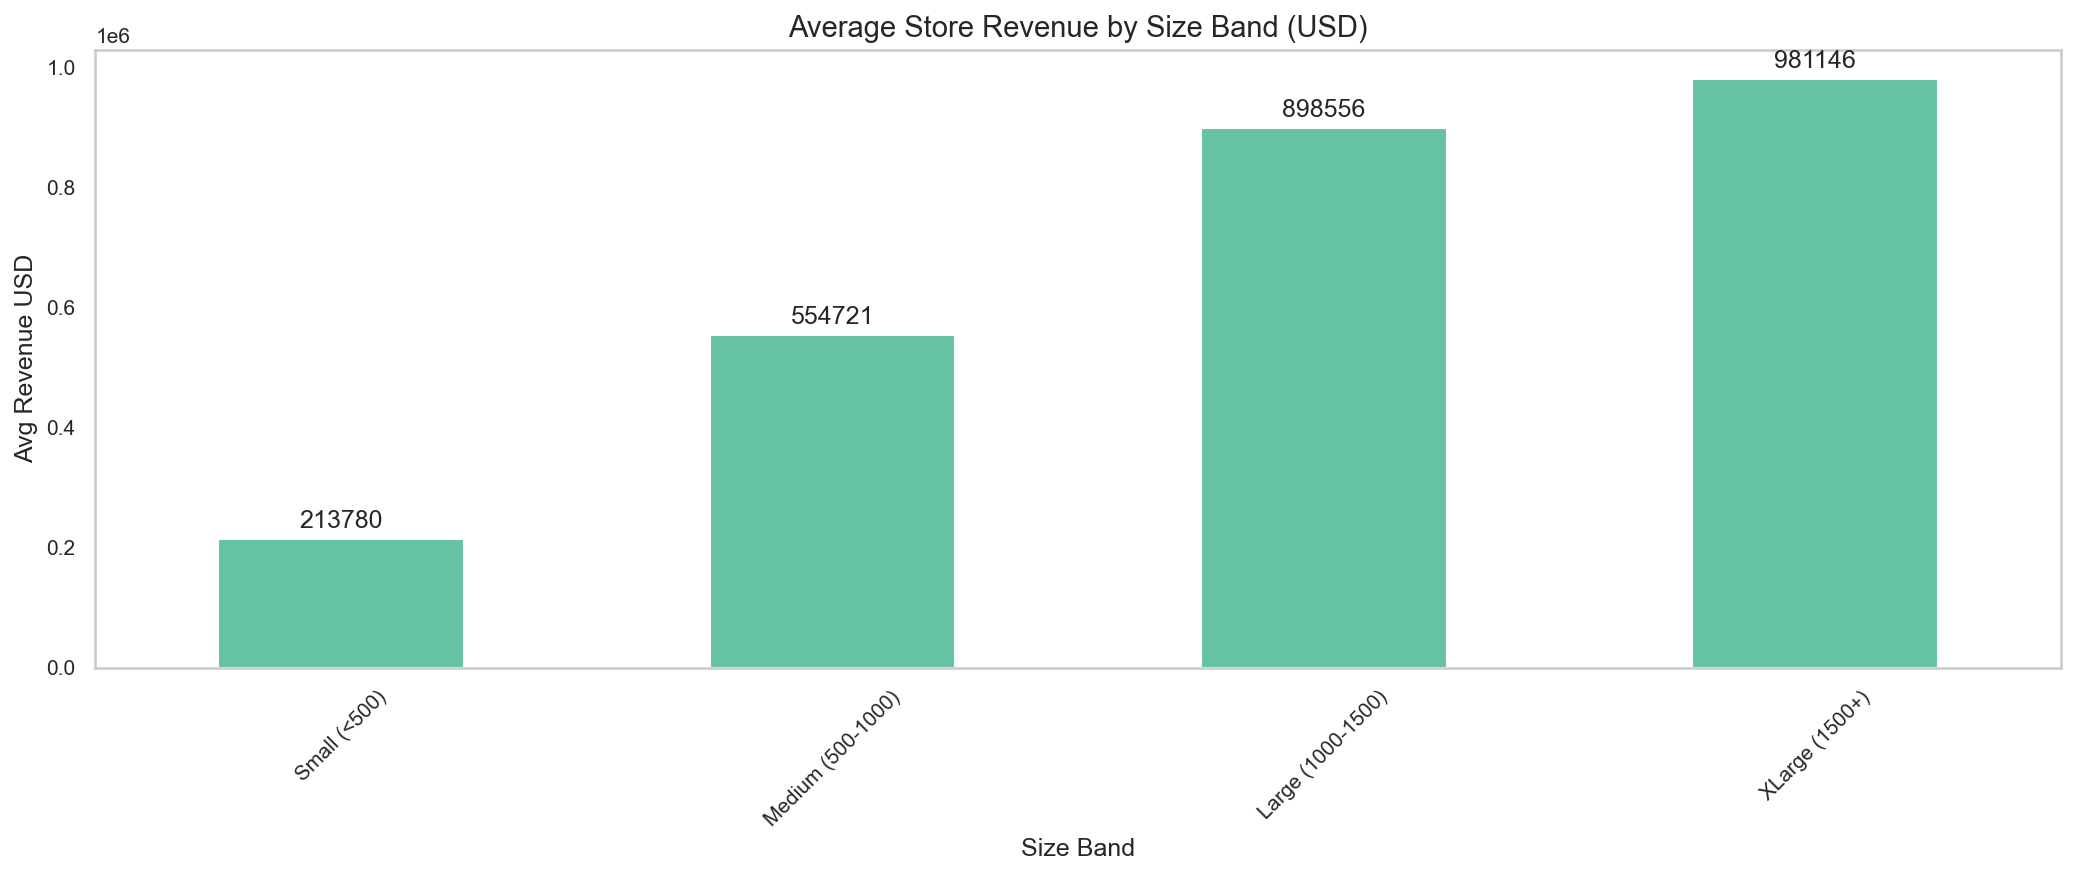

In [3]:
by_size = sp.revenue_by_size_band(stores, sales)
display(by_size)
fig, ax = base.bar(
    by_size.set_index("Size Band")["mean"],
    title="Average Store Revenue by Size Band (USD)",
    xlabel="Size Band", ylabel="Avg Revenue USD",
    filename="store_perf_by_size_band.png"
)

display(fig)

## Revenue by Country — Store Level

,Country,Store_Count,Total_Revenue,Avg_Revenue
0,United States,24,23764425.86,1188221.29
1,United Kingdom,7,7490416.02,1070059.43
2,Canada,5,2746999.61,915666.54
3,Italy,3,2330569.86,776856.62
4,Germany,9,4820198.25,602524.78
5,Netherlands,5,1805641.32,451410.33
6,Australia,6,1510207.43,302041.49
7,France,7,1396217.78,199459.68


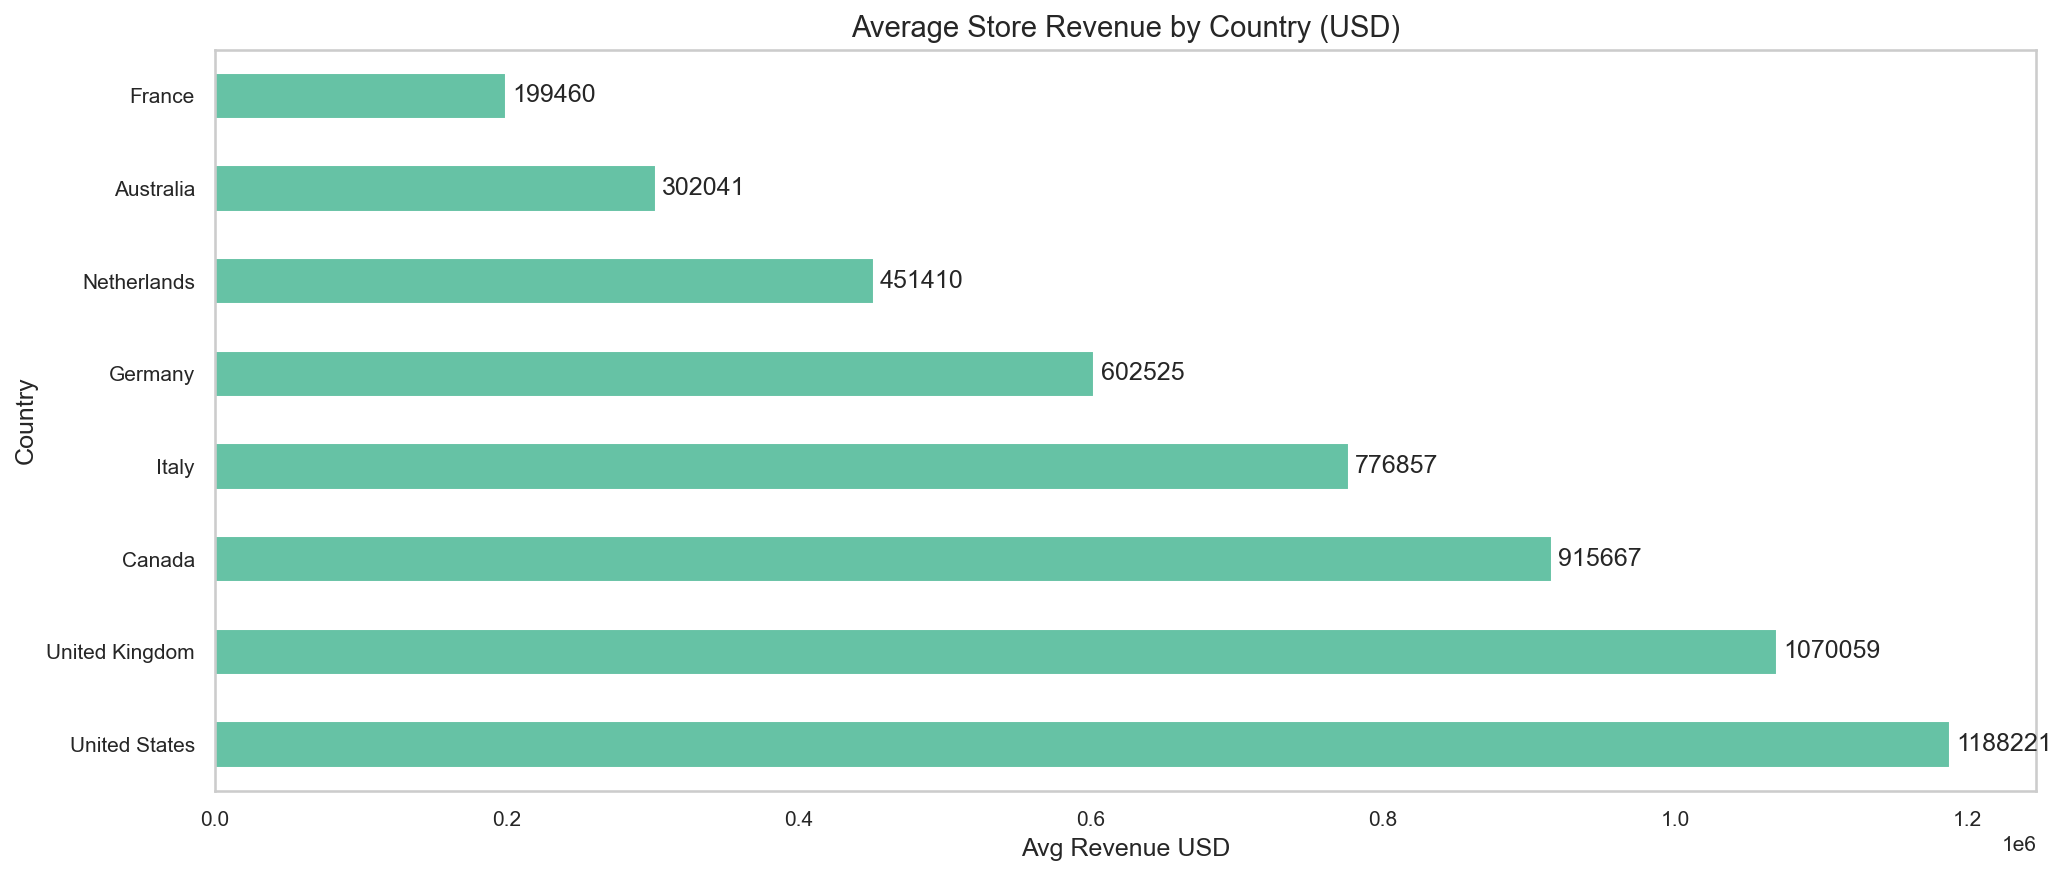

In [4]:
by_country = sp.revenue_by_country_store(stores, sales)
display(by_country)
fig, ax = base.horizontal_bar(
    by_country.set_index("Country")["Avg_Revenue"],
    title="Average Store Revenue by Country (USD)",
    xlabel="Avg Revenue USD", ylabel="Country",
    filename="store_perf_avg_by_country.png"
)

display(fig)

## Store Age vs Revenue

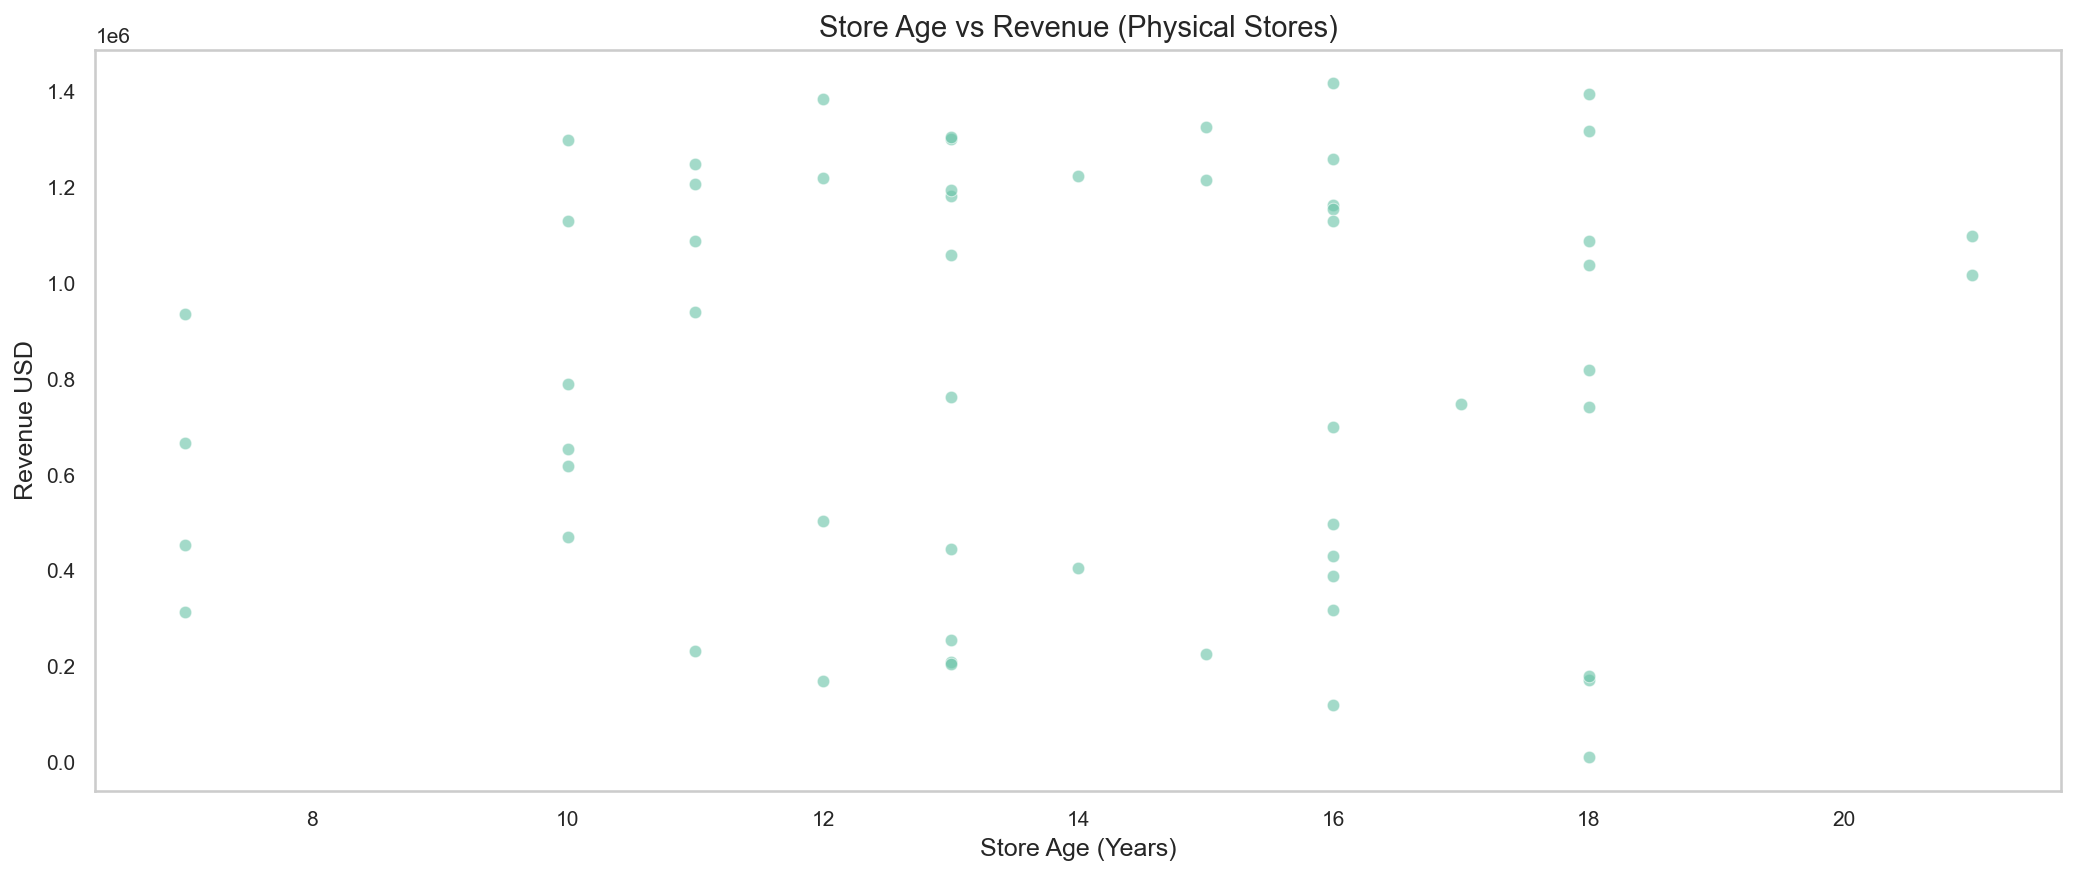

In [5]:
age_rev = sp.store_age_vs_revenue(stores, sales)
fig, ax = base.scatter(
    age_rev,
    x="Store Age Years",
    y="Revenue USD",
    title="Store Age vs Revenue (Physical Stores)",
    xlabel="Store Age (Years)",
    ylabel="Revenue USD",
    filename="store_perf_age_vs_revenue.png"
)

display(fig)

## Low Performing Stores (Revenue < $300K)

In [6]:
low = sp.low_performers(stores, sales, threshold=300000)
display(low)

,StoreKey,Country,Square Meters,Store Age Years,Revenue USD
1,2,Australia,665.0,18,11054.73
13,14,France,350.0,16,119423.55
12,13,France,245.0,12,170142.08
0,1,Australia,595.0,18,173092.39
16,17,France,350.0,18,181508.27
27,28,Italy,1200.0,13,204772.58
11,12,France,350.0,13,210166.41
15,16,France,385.0,15,226063.92
14,15,France,400.0,11,232891.87
17,18,France,310.0,13,256021.68


## Store Performance — Findings

### Size and Revenue
- Clear step-up pattern — bigger stores consistently earn more on average.
- Small stores (<500 sq m): avg $214K. XLarge (1500+ sq m): avg $981K — 4.6x difference.
- Size does have a meaningful relationship with revenue at the band level,
  even though individual scatter showed high variance.
- Small stores (mostly France) are structurally disadvantaged by their format.

### Country Performance
- US leads at $1.19M average per store, UK second at $1.07M.
- France is the clear underperformer at $199K per store — less than a fifth of US average.
- Australia ($302K) is also weak — high store count relative to revenue output.
- Italy ($777K) punches above its weight given it has only 3 stores.
- Netherlands ($451K) underperforms relative to its European peers.

### Store Age vs Revenue
- No meaningful relationship between store age and revenue.
- Strong and weak performers exist at every age from 7 to 21 years.
- Age of the store does not predict performance — confirms location and country matter more.
- One 18-year-old store shows near-zero revenue — likely the flagged low performer.

### Key Takeaway
- Country is the strongest predictor of store performance, not size or age.
- France stores are small and low revenue — both metrics point to a structurally weak market.
- Australia has decent store count but poor average revenue — underutilised footdisplay.
- US and UK stores are the backbone of the physical network.